In [30]:
import numpy as np
import matplotlib.pyplot as plt


In [8]:
def plot_spectrum(w_list, S3_topo, S3_triv, levels=60, figsize=(12, 14), save_path=None):
    """
    Displays a 3x2 figure with 2D spectra for the topological and trivial phases.
    Each subplot has its own (non-shared) color scale to reveal 
    the line shapes of low-amplitude signals.
    """
    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # ==========================================
    # ROW 1: REAL PART
    # ==========================================
    lim_real_topo = np.max(np.abs(np.real(S3_topo)))
    lim_real_triv = np.max(np.abs(np.real(S3_triv)))
    
    c00 = axes[0, 0].contourf(w_list, w_list, np.real(S3_topo), levels, 
                              cmap='RdBu_r', vmin=-lim_real_topo, vmax=lim_real_topo)
    axes[0, 0].set_title(r"Real / Topo ($t_2 > t_1$)")
    axes[0, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c00, ax=axes[0, 0])
    
    c01 = axes[0, 1].contourf(w_list, w_list, np.real(S3_triv), levels, 
                              cmap='RdBu_r', vmin=-lim_real_triv, vmax=lim_real_triv)
    axes[0, 1].set_title(r"Real / Triv ($t_1 > t_2$)")
    fig.colorbar(c01, ax=axes[0, 1])

    # ==========================================
    # ROW 2: IMAGINARY PART
    # ==========================================
    lim_imag_topo = np.max(np.abs(np.imag(S3_topo)))
    lim_imag_triv = np.max(np.abs(np.imag(S3_triv)))
    
    c10 = axes[1, 0].contourf(w_list, w_list, np.imag(S3_topo), levels, 
                              cmap='RdBu_r', vmin=-lim_imag_topo, vmax=lim_imag_topo)
    axes[1, 0].set_title(r"Imag / Topo ($t_2 > t_1$)")
    axes[1, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c10, ax=axes[1, 0])
    
    c11 = axes[1, 1].contourf(w_list, w_list, np.imag(S3_triv), levels, 
                              cmap='RdBu_r', vmin=-lim_imag_triv, vmax=lim_imag_triv)
    axes[1, 1].set_title(r"Imag / Triv ($t_1 > t_2$)")
    fig.colorbar(c11, ax=axes[1, 1])

    # ==========================================
    # ROW 3: ABSOLUTE VALUE
    # ==========================================
    lim_abs_topo = np.max(np.abs(S3_topo))
    lim_abs_triv = np.max(np.abs(S3_triv))
    
    c20 = axes[2, 0].contourf(w_list, w_list, np.abs(S3_topo), levels, 
                              cmap='magma', vmin=0, vmax=lim_abs_topo)
    axes[2, 0].set_title(r"Abs / Topo ($t_2 > t_1$)")
    axes[2, 0].set_xlabel(r"$\omega_1$")
    axes[2, 0].set_ylabel(r"$\omega_3$")
    fig.colorbar(c20, ax=axes[2, 0])
    
    c21 = axes[2, 1].contourf(w_list, w_list, np.abs(S3_triv), levels, 
                              cmap='magma', vmin=0, vmax=lim_abs_triv)
    axes[2, 1].set_title(r"Abs / Triv ($t_1 > t_2$)")
    axes[2, 1].set_xlabel(r"$\omega_1$")
    fig.colorbar(c21, ax=axes[2, 1])

    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved at: {save_path}")
        
    plt.show()

In [ ]:
def get_H_and_Js_numpy(k_array, t1, t2):
    N = len(k_array)
    H_mat = np.zeros((N, 2, 2), dtype=complex)
    H_mat[:, 0, 1] = t1 + t2 * np.exp(-1j * k_array)
    H_mat[:, 1, 0] = t1 + t2 * np.exp(1j * k_array)
    
    J_k_mat = np.zeros((N, 2, 2), dtype=complex)
    J_k_mat[:, 0, 1] = -1j * t2 * np.exp(-1j * k_array)
    J_k_mat[:, 1, 0] = 1j * t2 * np.exp(1j * k_array)
    
    J_minusk_mat = np.zeros((N, 2, 2), dtype=complex)
    J_minusk_mat[:, 0, 1] = -1j * t2 * np.exp(1j * k_array)
    J_minusk_mat[:, 1, 0] = 1j * t2 * np.exp(-1j * k_array)
    
    return H_mat, J_k_mat, J_minusk_mat

def get_thermal_state_numpy(H_mat, T, mu=0.0):
    # np.linalg.eigh fonctionne nativement sur un batch de matrices (N, 2, 2)
    evals, evecs = np.linalg.eigh(H_mat) 
    
    # Distribution de Fermi-Dirac (taille N, 2)
    f_occ = 1.0 / (np.exp((evals - mu) / T) + 1.0)
    
    rho_eq = np.zeros_like(H_mat)
    # Construction de rho_eq par produit externe pour chaque k
    for i in range(2):
        vec = evecs[:, :, i:i+1] # Vecteur propre i
        vec_dag = np.conj(vec.transpose(0, 2, 1))
        rho_eq += f_occ[:, i:i+1, np.newaxis] * (vec @ vec_dag)
        
    return rho_eq


def sigma_frohlich(omega, omega_LO, lam, eta, T):
    """Calculates the self-energy (complex scalar)."""
    n_ph = 1.0 / (np.exp(omega_LO / T) - 1.0)
    term1 = (n_ph + 1.0) / ((omega - omega_LO) + 1j * eta)
    term2 = n_ph / ((omega + omega_LO) + 1j * eta)
    return (lam**2) * (term1 + term2)

In [33]:
def spre_numpy(A):
    # Correspond à (I \otimes A) pour la convention "flatten('F')"
    N = A.shape[0]
    res = np.zeros((N, 4, 4), dtype=complex)
    res[:, 0:2, 0:2] = A
    res[:, 2:4, 2:4] = A
    return res

def spost_numpy(B):
    # Correspond à (B^T \otimes I)
    N = B.shape[0]
    res = np.zeros((N, 4, 4), dtype=complex)
    res[:, 0, 0] = B[:, 0, 0]; res[:, 1, 1] = B[:, 0, 0]
    res[:, 0, 2] = B[:, 1, 0]; res[:, 1, 3] = B[:, 1, 0]
    res[:, 2, 0] = B[:, 0, 1]; res[:, 3, 1] = B[:, 0, 1]
    res[:, 2, 2] = B[:, 1, 1]; res[:, 3, 3] = B[:, 1, 1]
    return res

In [34]:
def get_L_eff_numpy(H_mat, omega, omega_LO, lam, eta, T):
    Sigma = sigma_frohlich(omega, omega_LO, lam, eta, T)
    
    I_2 = np.eye(2)
    H_eff = H_mat + Sigma * I_2
    
    # L = spre(H_eff) - spost(H_eff)
    L_super = spre_numpy(H_eff) - spost_numpy(H_eff)
    return L_super

def get_green_functions_numpy(L_w1, L_w3, tau2, w1, w3, eta):
    N = L_w1.shape[0]
    I_4 = np.eye(4)
    
    # L'inversion matricielle est ultra-rapide et vectorisée
    G1_mat = np.linalg.inv((w1 + 1j * eta) * I_4 - L_w1)
    G3_mat = np.linalg.inv((w3 + 1j * eta) * I_4 - L_w3)
    
    # Calcul vectorisé de expm(-1j * L * tau2) via diagonalisation
    evals, evecs = np.linalg.eig(-1j * L_w1 * tau2) 
    evecs_inv = np.linalg.inv(evecs)
    exp_D = np.exp(evals) 
    
    G2_mat = (evecs * exp_D[:, np.newaxis, :]) @ evecs_inv
    
    return G1_mat, G2_mat, G3_mat

In [35]:
def calc_rephasing_S3_vectorized(k_array, w3, w1, tau2, params):
    t1, t2 = params["t1"], params["t2"]
    eta, T = params["Eta"], params["T"]
    wLO, lam, mu = params["omegaLO"], params["lambda"], params["mu"]
    
    # 1. Génération des blocs
    H_mat, J_k_mat, J_minusk_mat = get_H_and_Js_numpy(k_array, t1, t2)
    rho_eq = get_thermal_state_numpy(H_mat, T, mu)
    
    # 2. Superopérateurs
    JL1 = spre_numpy(J_k_mat)
    JR1 = spost_numpy(J_k_mat)
    JL2 = spre_numpy(J_minusk_mat)
    JR2 = spost_numpy(J_minusk_mat)
    JR3 = spost_numpy(J_minusk_mat)
    JL_out = spre_numpy(J_k_mat)
    
    # 3. Propagateurs
    L_w1 = get_L_eff_numpy(H_mat, w1, wLO, lam, eta, T)
    L_w3 = get_L_eff_numpy(H_mat, w3, wLO, lam, eta, T)
    G1, G2, G3 = get_green_functions_numpy(L_w1, L_w3, tau2, w1, w3, eta)
    
    # 4. Aplatissement de la matrice de densité (équivalent 'F' de numpy/QuTiP)
    N = len(k_array)
    rho_vec = np.zeros((N, 4, 1), dtype=complex)
    rho_vec[:, 0, 0] = rho_eq[:, 0, 0]
    rho_vec[:, 1, 0] = rho_eq[:, 1, 0]
    rho_vec[:, 2, 0] = rho_eq[:, 0, 1]
    rho_vec[:, 3, 0] = rho_eq[:, 1, 1]
    
    # 5. Multiplications matricielles séquentielles (@ est automatiquement vectorisé)
    path_GSB = G3 @ (JR3 @ (G2 @ (JL2 @ (G1 @ (JL1 @ rho_vec)))))
    path_SE  = G3 @ (JR3 @ (G2 @ (JL2 @ (G1 @ (JR1 @ rho_vec)))))
    path_ESA = G3 @ (JR3 @ (G2 @ (JR2 @ (G1 @ (JR1 @ rho_vec)))))
    
    # 6. Traces finales
    I_vec = np.zeros((N, 1, 4), dtype=complex)
    I_vec[:, 0, 0] = 1.0 # Correspond à np.eye(2).flatten('F')
    I_vec[:, 0, 3] = 1.0
    
    tr_GSB = -1j * (I_vec @ (JL_out @ path_GSB)).reshape(-1)
    tr_SE  = -1j * (I_vec @ (JL_out @ path_SE)).reshape(-1)
    tr_ESA = -1j * (I_vec @ (JL_out @ path_ESA)).reshape(-1)
    
    total_trace = tr_GSB + tr_SE + tr_ESA
    
    return total_trace



In [36]:
def generate_2D_spectrum_vectorized(w1_list, w3_list, tau2, params, n_kpoints):
    k_array = np.linspace(-np.pi, np.pi, n_kpoints)
    dk = k_array[1] - k_array[0]
    
    S3_grid = np.zeros((len(w3_list), len(w1_list)), dtype=complex)
    
    # Boucle unique sur les fréquences
    for i, w3 in enumerate(w3_list):
        for j, w1 in enumerate(w1_list):
            
            # APPEL UNIQUE: Calcule instantanément la réponse pour les 100 000 k-points
            S3_vec = calc_rephasing_S3_vectorized(k_array, w3, w1, tau2, params)
            
            # Intégration sur k
            S3_grid[i, j] = np.sum(S3_vec) * dk / (2 * np.pi)
            
    return S3_grid

In [37]:
TOTAL_KPOINTS = 50
w_list = np.linspace(0.5, 1.5, 500) 
tau2_test = 3.0  # Updated according to your file
    
params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
print(f"Calcul avec {TOTAL_KPOINTS} points (100% Vectorisé NumPy)...")

S3_topo = generate_2D_spectrum_vectorized(
    w_list, w_list, tau2_test, params_topo, n_kpoints=TOTAL_KPOINTS
)

S3_triv = generate_2D_spectrum_vectorized(
    w_list, w_list, tau2_test, params_triv, n_kpoints=TOTAL_KPOINTS
)

Calcul avec 50 points (100% Vectorisé NumPy)...


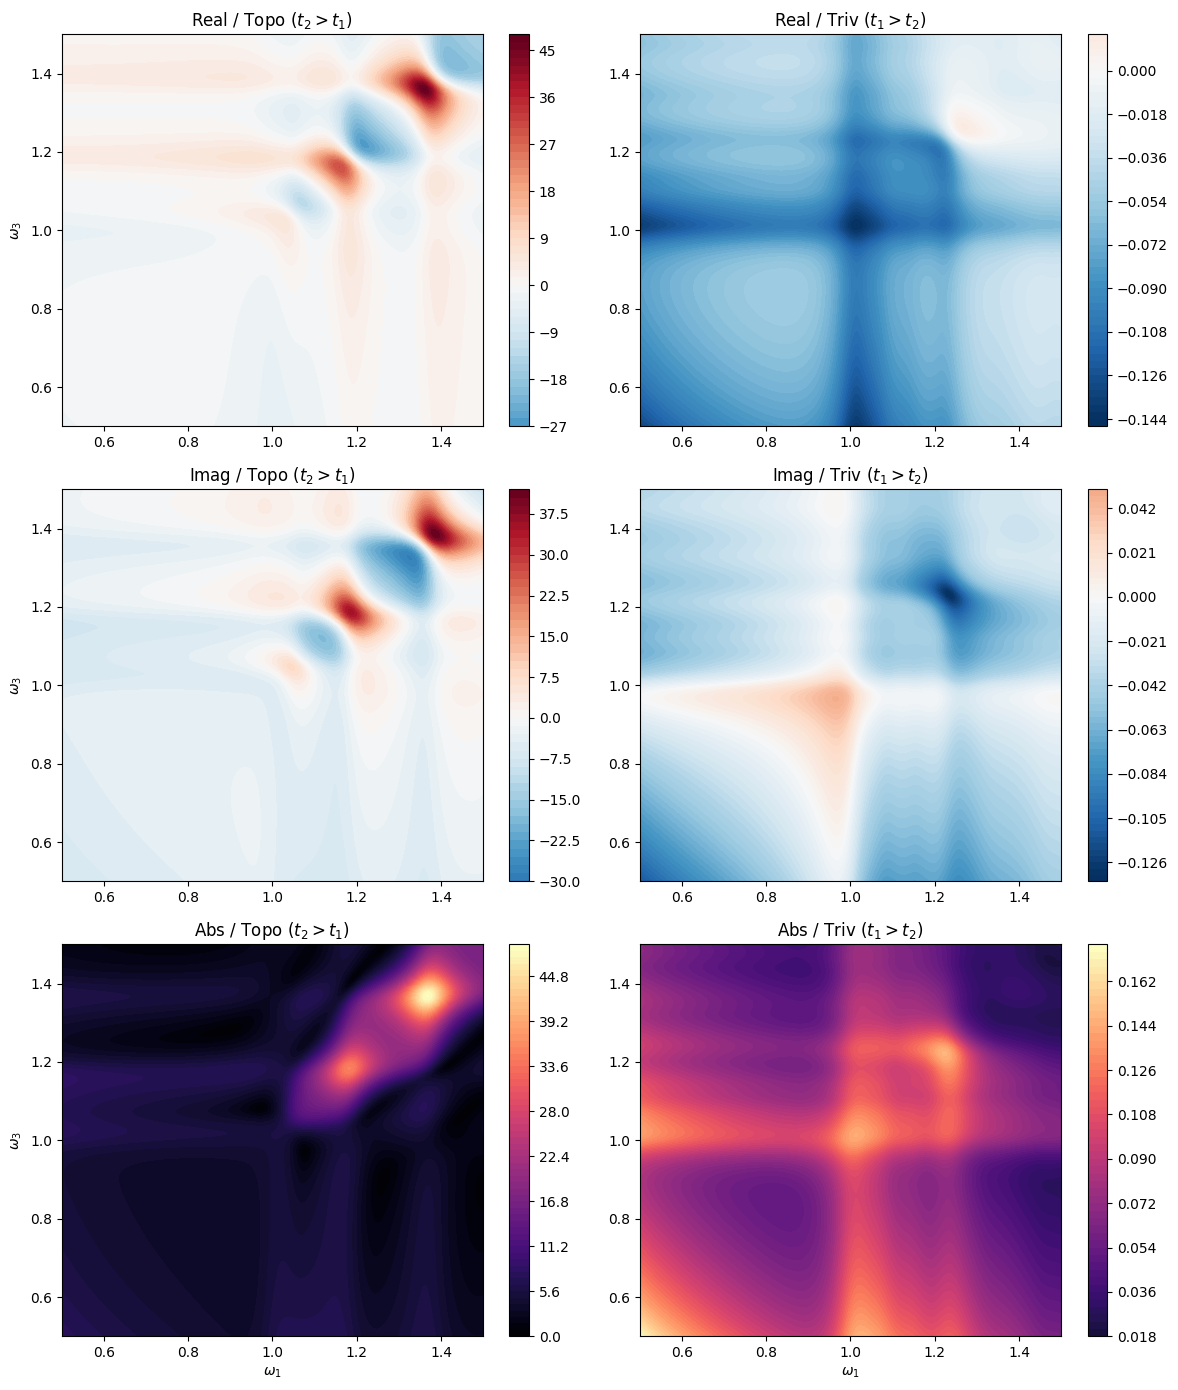

In [38]:
plot_spectrum(w_list, S3_topo, S3_triv)

In [ ]:
from LiouvilleSpectroscopy import LiouvilleSpectroscopySolver
import numpy as np



def build_raw_tensors(k_array, t1,t2):
    N = len(k_array)
    d = 2 # ou 3, 4, etc.
    
    H_raw = np.zeros((N, d, d), dtype=complex)
    H_raw[:, 0, 1] = t1 + t2 * np.exp(-1j * k_array)
    H_raw[:, 1, 0] = t1 + t2 * np.exp(1j * k_array)

    J_raw = np.zeros((N, d, d), dtype=complex)
    J_raw[:, 0, 1] = -1j * t2 * np.exp(-1j * k_array)
    J_raw[:, 1, 0] =  1j * t2 * np.exp(1j * k_array)
    
    

    # Tu retournes les matrices brutes. PAS de diagonalisation ici !
    return H_raw, J_raw



TOTAL_KPOINTS = 100
w_list = np.linspace(-1.5, 1.5, 100) 
tau2_test = 3.0  # Updated according to your file
    
params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
print(f"Calcul avec {TOTAL_KPOINTS} points (100% Vectorisé NumPy)...")



t1_topo, t2_topo = params_topo["t1"], params_topo["t2"]
t1_triv, t2_triv = params_triv["t1"], params_triv["t2"]

k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)
dk = k_array[1] - k_array[0]

H_topo,J_raw_topo= build_raw_tensors(k_array, t1_topo,t2_topo)

H_triv,J_raw_triv= build_raw_tensors(k_array, t1_triv,t2_triv)




# 1. Tu instancies le solveur avec tes paramètres physiques
solveur = LiouvilleSpectroscopySolver(params_topo)

# 2. Tu injectes tes tenseurs NumPy générés en amont avec QuTiP
solveur.feed_model(H_triv, J_raw_topo)

# 3. Tu ajoutes tes opérateurs de dissipation de Lindblad (ex: relaxation de bande)
# Le solveur sait qu'il s'agit de tenseurs complets sur l'axe k
c_ops = [(solveur.J_minus, 0.05)] 
solveur.set_dissipation(c_ops)

# 4. Tu extrais l'ensemble des spectres d'un seul coup
spectres = solveur.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)

# Tes données sont prêtes pour ton visualiseur !
S3_pure_rephasing_topo= spectres["rephasing"]
S3_pure_unrephasing_topo = spectres["unrephasing"]


# 1. Tu instancies le solveur avec tes paramètres physiques
solveur = LiouvilleSpectroscopySolver(params_triv)

# 2. Tu injectes tes tenseurs NumPy générés en amont avec QuTiP
solveur.feed_model(H_triv, J_raw_triv)

# 3. Tu ajoutes tes opérateurs de dissipation de Lindblad (ex: relaxation de bande)
# Le solveur sait qu'il s'agit de tenseurs complets sur l'axe k
c_ops = [(solveur.J_minus, 0.05)] 
solveur.set_dissipation(c_ops)

# 4. Tu extrais l'ensemble des spectres d'un seul coup
spectres = solveur.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)

# Tes données sont prêtes pour ton visualiseur !
S3_pure_rephasing_triv= spectres["rephasing"]
S3_pure_unrephasing_triv = spectres["unrephasing"]

Calcul avec 500 points (100% Vectorisé NumPy)...


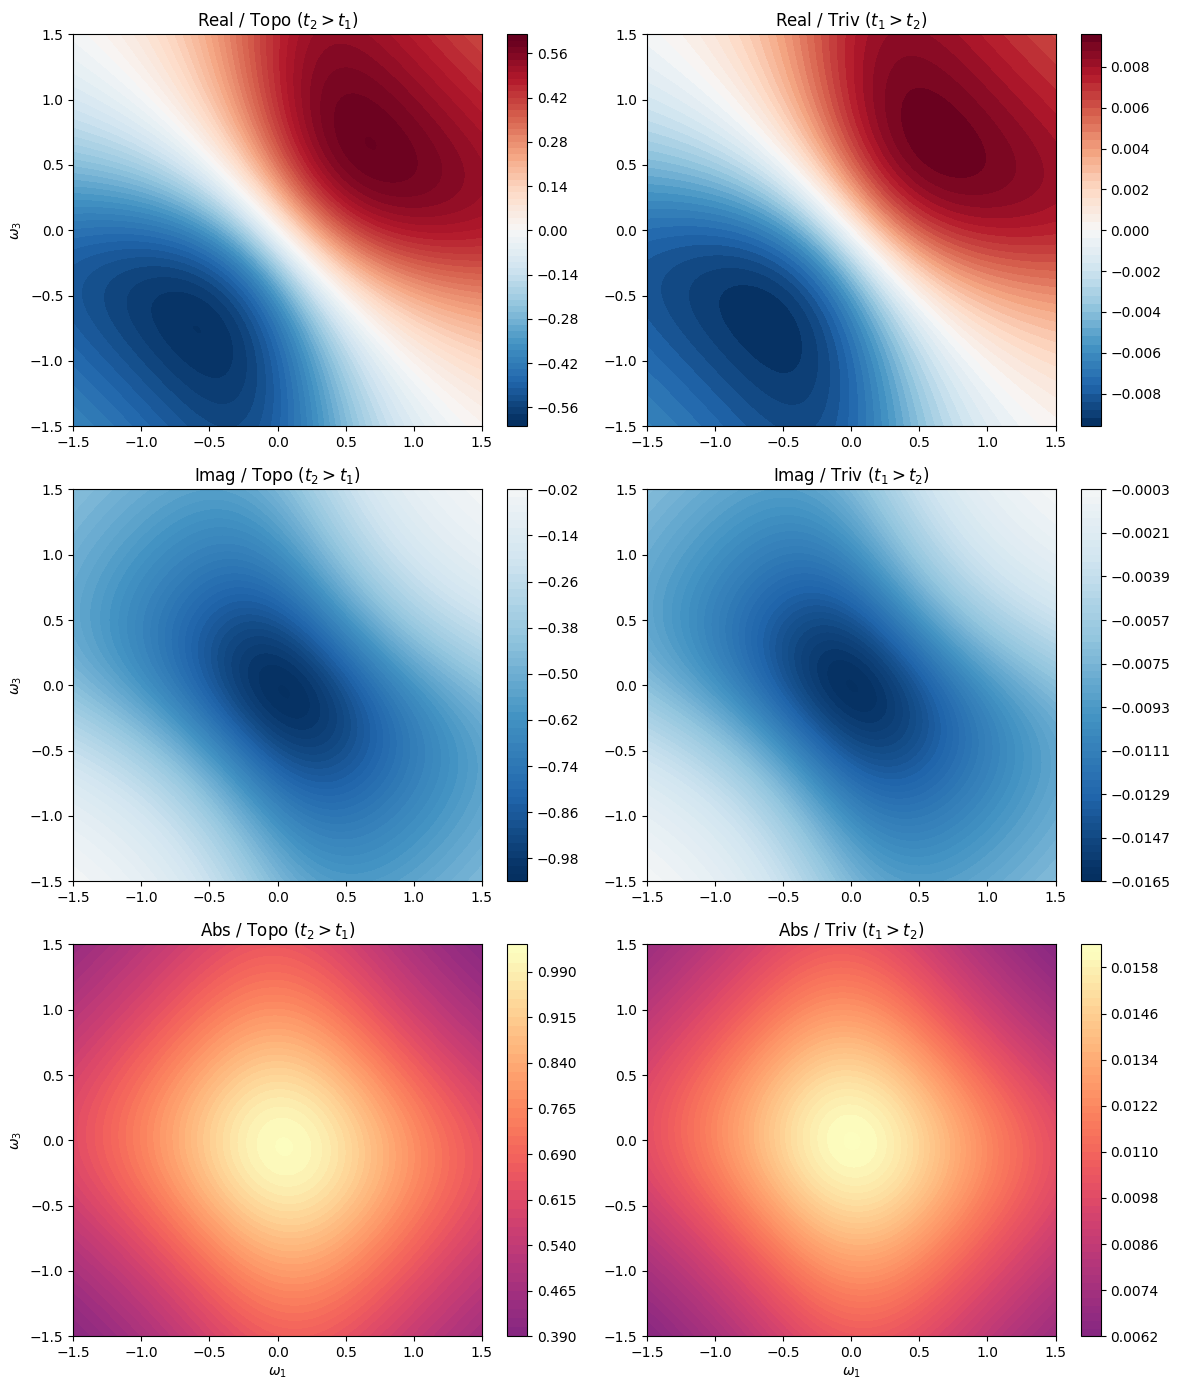

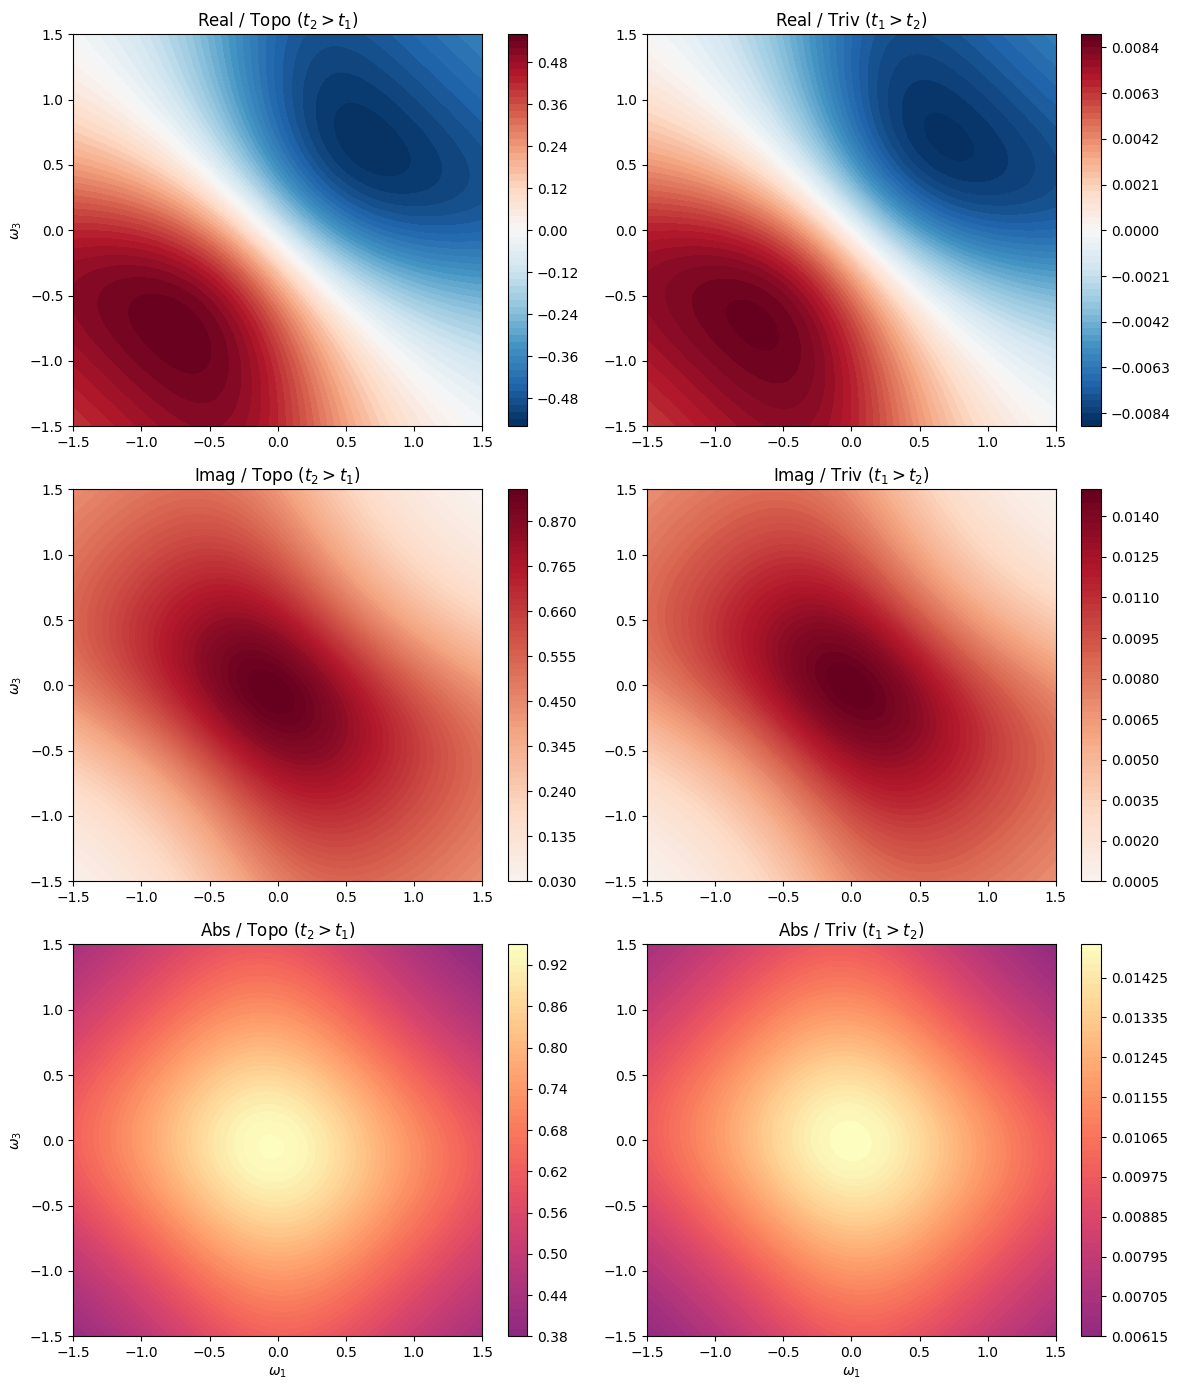

In [24]:
import matplotlib.pyplot as plt
plot_spectrum(w_list,S3_pure_rephasing_topo,S3_pure_rephasing_triv)

plot_spectrum(w_list,S3_pure_unrephasing_topo,S3_pure_unrephasing_triv)